In [31]:
import numpy as np
import matplotlib.pyplot as plt
from herculens.Coordinates.pixel_grid import PixelGrid
from herculens.Instrument.noise import Noise
from herculens.Instrument.psf import PSF
from herculens.MassModel.mass_model import MassModel
from herculens.LightModel.light_model import LightModel
from herculens.LensImage.lens_image import LensImage

In [32]:
# hubble resolution, noise and psf
exposure_time = 600 # seconds
fov = 2.0 # arcseconds
pix_scale = 0.04 # arcseconds
nx, ny = (int(fov/pix_scale), int(fov/pix_scale))

# these are down scaled by a factor of a thousand
read_noise = 8.7e-3 # e- rms
dark_current = 4.1e-5 # e-/s/pixel

signal_to_noise = 50

hubble_psf = np.load("psf/hubble_psf.npy")

In [33]:
# what is the physical coordinate of the (0, 0) corner pixel?
half_size_x = fov/2
half_size_y = fov/2
ra_at_xy_0 = -half_size_x + pix_scale/2
dec_at_xy_0 = -half_size_y + pix_scale/2

transform_pix2angle = pix_scale*np.eye(2)
kwargs_pixel = {
    'nx': nx,
    'ny': ny,
    'ra_at_xy_0': ra_at_xy_0,
    'dec_at_xy_0': dec_at_xy_0,
    'transform_pix2angle': transform_pix2angle
}

# herculens' pixel grid class handles everything
pixel_grid = PixelGrid(**kwargs_pixel)

# useful things we might need from it
xgrid, ygrid = pixel_grid.pixel_coordinates
x_axis = xgrid[0]
y_axis = ygrid[:, 0]
extent = pixel_grid.extent
x_grid, y_grid = np.meshgrid(x_axis, y_axis)   

In [34]:
noise = Noise(nx, ny, background_rms=read_noise, exposure_time=exposure_time)
psf = PSF(
    psf_type='PIXEL', 
    pixel_size=pix_scale, 
    kernel_point_source=hubble_psf, 
    kernel_supersampling_factor=4
    )

In [35]:
lens_mass_model = MassModel(['EPL', 'SHEAR']) # add deflection angles together: elliptical power law with external shear
lens_light_model = LightModel(['SERSIC_ELLIPSE']) # elliptical sersic profile
source_light_model = LightModel(['SERSIC_ELLIPSE']) 

In [36]:
lens_EPL_kwargs = {
    'theta_E': 0.8,
    'gamma': 2.05,
    'e1': 0.2,
    'e2': 0,
    'center_x': 0.0,
    'center_y': 0.0
}
lens_shear_kwargs = {
    'gamma1': 0.0,
    'gamma2': -0.03,
    'ra_0': lens_EPL_kwargs['center_x'],    # center external shear on lens
    'dec_0': lens_EPL_kwargs['center_y'],   # center external shear on lens
}
lens_mass_kwargs = [lens_EPL_kwargs, lens_shear_kwargs]

# convergence
lens_kappa = lens_mass_model.kappa(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)

# shear
lens_gamma = lens_mass_model.gamma(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)
lens_gamma_1, lens_gamma_2 = lens_gamma

# deflection angle
lens_alpha = lens_mass_model.alpha(x=x_grid, y=y_grid, kwargs=lens_mass_kwargs)
lens_alpha_x, lens_alpha_y = lens_alpha

In [37]:
lens_sersic_kwargs = {
    'amp': signal_to_noise * 1.0,
    'R_sersic': 0.2,
    'n_sersic': 4.0, # n=4: de Vaucouleurs profile
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}

lens_light_kwargs = [lens_sersic_kwargs]

In [38]:
source_sersic_kwargs = {
    'amp': signal_to_noise * 1.0,
    'R_sersic': 0.03,
    'n_sersic': 1.0, # n=1: exponential profile
    'e1': 0.0,
    'e2': 0.1,
    'center_x': 0.0,
    'center_y': 0.0
}

source_light_kwargs = [source_sersic_kwargs]

In [39]:
lens_light_prof = lens_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=lens_light_kwargs)
source_light_prof = source_light_model.surface_brightness(x=x_grid, y=y_grid, kwargs=source_light_kwargs) # bare in mind that this is computed from image plane coordinates

Text(0.5, 1.0, 'source light')

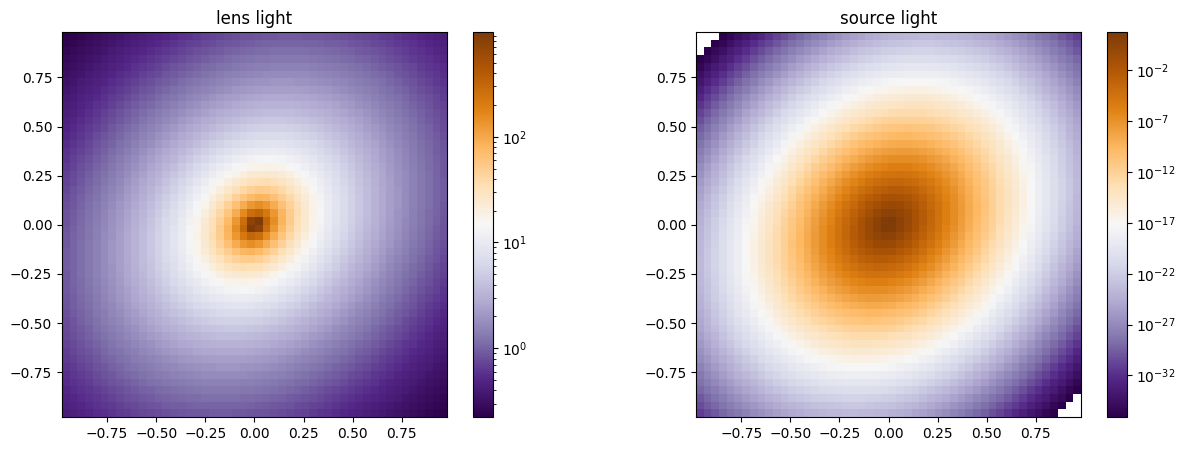

In [40]:
# what do the lens and source look like?

plt.figure(figsize=(15, 5))

plt.subplot(121)
plt.imshow(lens_light_prof, origin='lower', cmap='PuOr_r', norm='log', extent=extent)
plt.colorbar()
plt.title('lens light')

plt.subplot(122)
plt.imshow(source_light_prof, origin='lower', cmap='PuOr_r',  norm='log', extent=extent)
plt.colorbar()
plt.title('source light')

In [41]:
# handles stuff that needs ray tracing
lens_image = LensImage(
    grid_class=pixel_grid,
    psf_class=psf,
    noise_class=noise,
    lens_mass_model_class=lens_mass_model,
    lens_light_model_class=lens_light_model,
    source_model_class=source_light_model
)

lens_image.model?

Signature:
lens_image.model(
    kwargs_lens=None,
    kwargs_source=None,
    kwargs_lens_light=None,
    kwargs_point_source=None,
    unconvolved=False,
    supersampled=False,
    source_add=True,
    lens_light_add=True,
    point_source_add=True,
    k_lens=None,
    k_source=None,
    k_lens_light=None,
    k_point_source=None,
    adapted_source_pixels_coords=None,
    return_source_pixels_coords=False,
)
Docstring:
Create the 2D model image from parameter values.
Note: due to JIT compilation, the first call to this method will be slower.

:param kwargs_lens: list of keyword arguments corresponding to the superposition of different lens profiles
:param kwargs_source: list of keyword arguments corresponding to the superposition of different source light profiles
:param kwargs_lens_light: list of keyword arguments corresponding to different lens light surface brightness profiles
:param kwargs_point_source: keyword arguments corresponding to "other" parameters, such as external sh

In [42]:
model_image = lens_image.model(
    kwargs_lens=lens_mass_kwargs, 
    kwargs_source=source_light_kwargs, 
    kwargs_lens_light=lens_light_kwargs, 
    unconvolved=True
    )

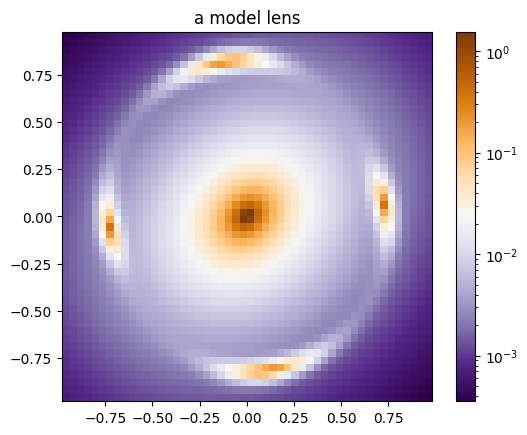

In [43]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('a model lens')
plt.savefig("figures_out/lensed_image.png")
plt.show()

In [44]:
model_image = lens_image.simulation(unconvolved=False, kwargs_lens=lens_mass_kwargs, kwargs_source=source_light_kwargs, kwargs_lens_light=lens_light_kwargs)

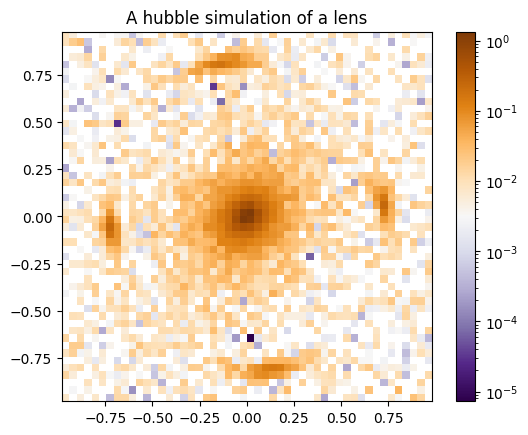

In [45]:
plt.imshow(model_image, origin='lower', cmap='PuOr_r',  extent=extent, norm='log')
plt.colorbar()
plt.title('A hubble simulation of a lens')
plt.savefig("figures_out/hubble_lens.png")
plt.show()